In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../classification_results_trial_0001.csv')
data.head()

,image_path,real_class,predicted_class,prob_benign,prob_malign
0,image_001.jpg,malign,malign,0.031429,0.968571
1,image_002.jpg,benign,benign,0.636410,0.363590
2,image_003.jpg,malign,malign,0.314356,0.685644
3,image_004.jpg,benign,benign,0.508571,0.491429
4,image_005.jpg,benign,benign,0.907566,0.092434


# Gráficos

## Contagem real class

Text(0, 0.5, 'Count')

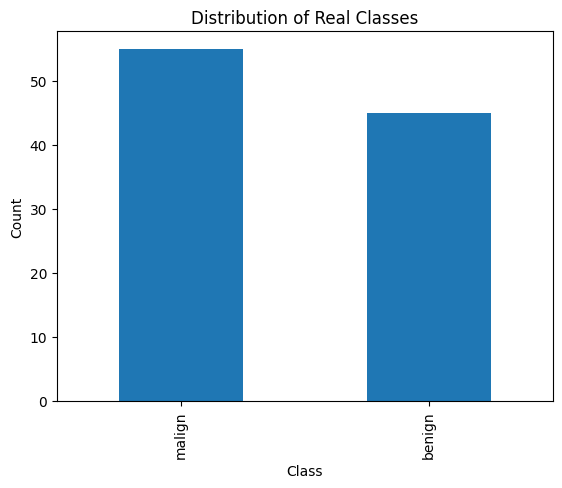

In [4]:
data['real_class'].value_counts().plot(kind='bar')

plt.title('Distribution of Real Classes')
plt.xlabel('Class')
plt.ylabel('Count')

## Contagem predicted class

Text(0, 0.5, 'Count')

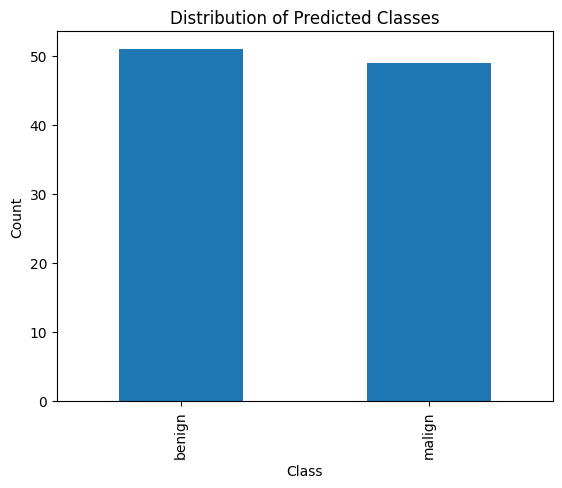

In [5]:
data['predicted_class'].value_counts().plot(kind='bar')

plt.title('Distribution of Predicted Classes')
plt.xlabel('Class')
plt.ylabel('Count')

## Histograma prob benign

Text(0, 0.5, 'Frequency')

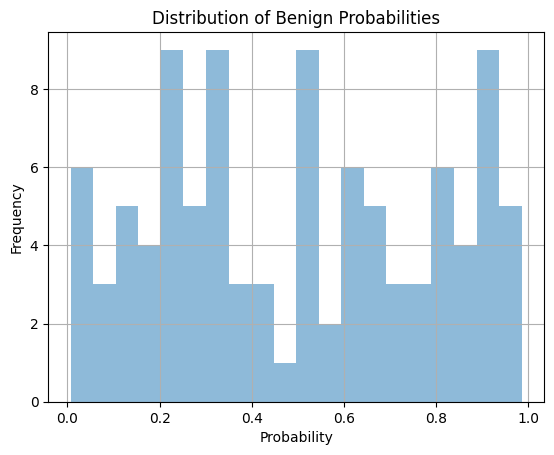

In [7]:
data['prob_benign'].hist(bins=20, alpha=0.5, label='Benign')

plt.title('Distribution of Benign Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')


## Histograma prob malign

Text(0, 0.5, 'Frequency')

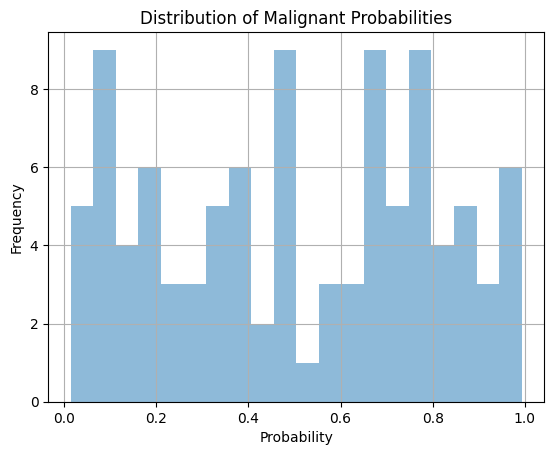

In [9]:
data['prob_malign'].hist(bins=20, alpha=0.5, label='Malignant')

plt.title('Distribution of Malignant Probabilities')
plt.xlabel('Probability')
plt.ylabel('Frequency')

## Scatter plot

In [11]:
data['erros'] = data['real_class'] != data['predicted_class']

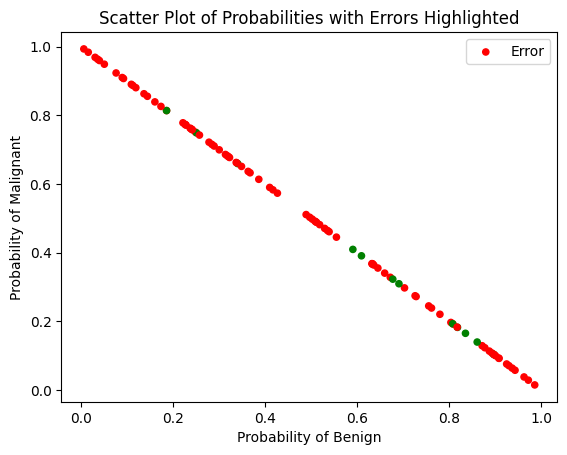

In [ ]:
data[['prob_benign', 'prob_malign']].plot(kind='scatter', x='prob_benign', y='prob_malign', c=data['erros'].map({True: 'green', False: 'red'})),

plt.title('Scatter Plot of Probabilities with Errors Highlighted')
plt.xlabel('Probability of Benign')
plt.ylabel('Probability of Malignant')


## Erro mais comum

In [18]:
FP = len(data[(data['real_class'] == 'benign') & (data['predicted_class'] == 'malign')])
FN = len(data[(data['real_class'] == 'malign') & (data['predicted_class'] == 'benign')])
print(FP, FN)

3 9


FN são mais comuns. <br>
Em um contexto médico, falsos negativos são mais preocupantes. Isso porque a negligência de um tratamento em uma pessoa doente tem um custo maior que o excesso de tratamento em uma pessoa saudável

Text(0, 0.5, 'Count')

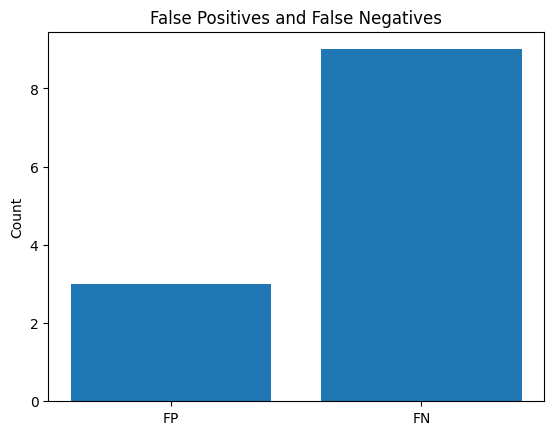

In [19]:
plt.bar(['FP', 'FN'], [FP, FN])

plt.title('False Positives and False Negatives')
plt.ylabel('Count')


# Curvas

In [21]:
metrics = pd.read_csv('../metrics.csv')
metrics.head()

,train_loss,val_loss,train_acc,val_acc
0,1.299380,1.037020,0.397652,0.604396
1,1.019229,0.745705,0.589824,0.703297
2,0.793183,0.611423,0.684932,0.747253
3,0.649150,0.524193,0.749902,0.769231
4,0.568477,0.444665,0.772211,0.791209


Text(0, 0.5, 'Loss')

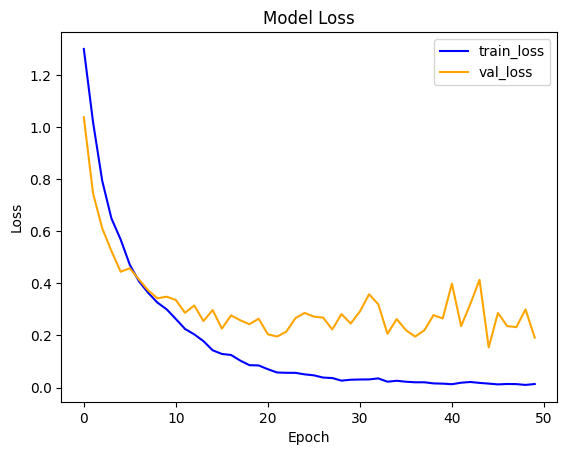

In [24]:
metrics[['train_loss', 'val_loss']].plot(kind='line', color=['blue', 'orange'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

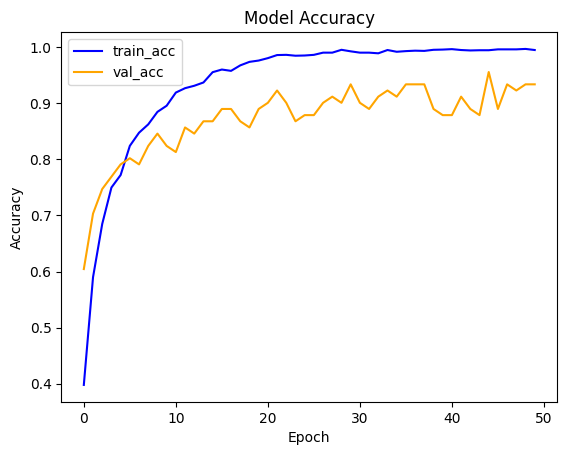

In [25]:
metrics[['train_acc', 'val_acc']].plot(kind='line', color=['blue', 'orange'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')